In [1]:
import pandas as pd
from process_and_save_recording import load_recording, convert_events_to_watch_time
from plot_signal import plot_signal

In [2]:
path = "session_1777462103399"
accel, gyro, classification, annotation, info = load_recording(path)

In [3]:
events_watch_time = convert_events_to_watch_time(annotation, info)

In [4]:
events_watch_time

[{'name': 'Crunches',
  'start_watch': 1777462349384,
  'end_watch': 1777462393955},
 {'name': 'Goblet Squats',
  'start_watch': 1777462620883,
  'end_watch': 1777462645157},
 {'name': 'Goblet Squats',
  'start_watch': 1777463015180,
  'end_watch': 1777463039059},
 {'name': 'Single Leg Romanian Deadlifts',
  'start_watch': 1777463468261,
  'end_watch': 1777463528203},
 {'name': 'Single Leg Romanian Deadlifts',
  'start_watch': 1777463830558,
  'end_watch': 1777463887162},
 {'name': 'Incline Dumbbell Bench Press',
  'start_watch': 1777464180380,
  'end_watch': 1777464207393},
 {'name': 'Incline Dumbbell Bench Press',
  'start_watch': 1777464459281,
  'end_watch': 1777464483773},
 {'name': 'Incline Dumbbell Curls',
  'start_watch': 1777464741084,
  'end_watch': 1777464796011},
 {'name': 'Incline Dumbbell Curls',
  'start_watch': 1777465018561,
  'end_watch': 1777465060599},
 {'name': 'Dips', 'start_watch': 1777465398863, 'end_watch': 1777465416018},
 {'name': 'Dips', 'start_watch': 17774

In [5]:
classification

,timestamp,prediction_float,prediction_binary,accel_timestamps,gyro_timestamps,window_data
0,1777462104036,0.014872,0,177015324722883;177015342756614;17701536279134...,177015324725345;177015342759306;17701536279380...,0.05267244|-0.3184288|9.730036|0.29443705|0.06...
1,1777462105052,0.029558,0,177016325628379;177016345636302;17701636572268...,177016325630687;177016345638879;17701636572503...,0.29927522|-0.5315128|9.78989|-0.02321288|-0.0...
2,1777462106060,0.037717,0,177017327272222;177017347310414;17701736735202...,177017327274529;177017347312952;17701736735437...,0.18914193|-0.093373865|9.816227|-0.040317107|...
3,1777462107050,0.077905,0,177018329547910;177018349617218;17701837170094...,177018329550218;177018349619795;17701837170325...,0.15083471|-0.21787235|9.706094|-0.040317107|0...
4,1777462108072,0.003745,0,177019333760522;177019351794829;17701937183232...,177019333764791;177019351797406;17701937183463...,-0.47405192|-0.50278234|9.797073|-0.04886922|-...
...,...,...,...,...,...,...
7184,1777469763270,0.350637,0,184654974690783;184654994774052;18465501486128...,184654974693244;184654994776244;18465501486370...,2.7030537|-8.990228|-3.217807|-0.41538838|0.01...
7185,1777469764491,0.302763,0,184674774326438;184674794412015;18467481449793...,184674774328630;184674794414438;18467481450016...,5.33907|-11.145009|3.3566709|-0.33108896|-0.45...
7186,1777469787305,0.022782,0,184676763719046;184676781513892;18467680161043...,184676763721469;184676781516084;18467680161289...,4.0198646|-7.788338|-0.107739076|0.16371189|0....
7187,1777469788308,0.010067,0,184677766438004;184677786552427;18467780667288...,184677766440427;184677786554619;18467780667531...,8.671799|-2.2098482|-1.5466543|0.9334021|0.076...


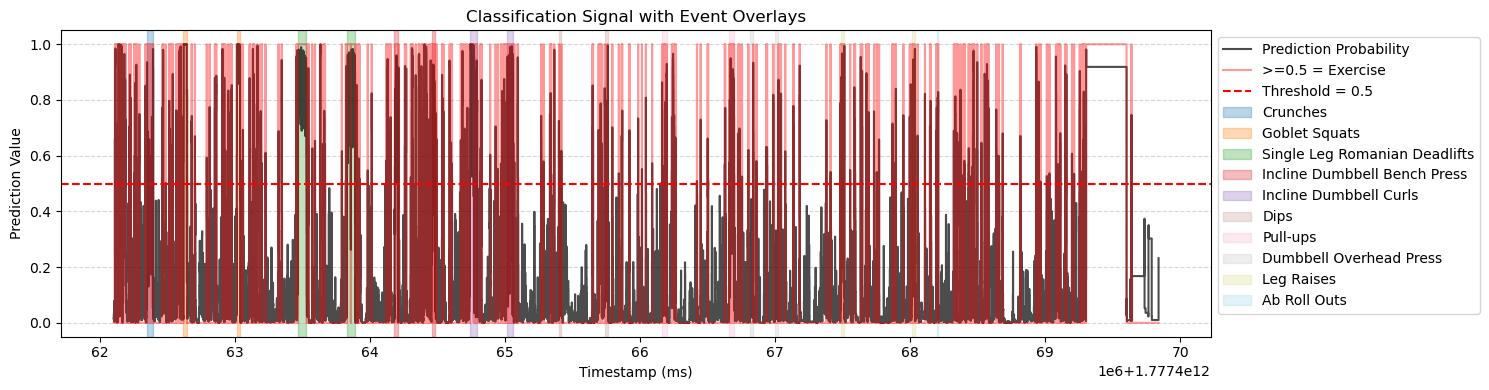

In [6]:
plot_signal(classification, events_watch_time)

In [7]:
# ignore treadmill running
ignore_list = ['Treadmill Running', 'Side Crunches',
               #'Chest Fly Machine', 'Dumbbell Overhead Press', 'Cable Rows'
               ]
filtered_events = [e for e in events_watch_time if e['name'] not in ignore_list]

# Metrics

In [8]:
def calculate_total_metrics(classification, events):
    df = classification.copy()
    
    # 1. Create Ground Truth (0 = Rest, 1 = Exercise)
    df['ground_truth'] = 0
    for event in events:
        mask = (df['timestamp'] >= event['start_watch']) & (df['timestamp'] <= event['end_watch'])
        df.loc[mask, 'ground_truth'] = 1
    
    # 2. Calculate Overall Accuracy
    # (How many times did prediction match ground truth exactly?)
    correct_total = (df['prediction_binary'] == df['ground_truth']).sum()
    total_preds = len(df)
    overall_accuracy = (correct_total / total_preds) * 100
    
    # 3. Breakdown by Class
    # Exercise Accuracy (Recall)
    exercise_mask = (df['ground_truth'] == 1)
    correct_exercise = (df.loc[exercise_mask, 'prediction_binary'] == 1).sum()
    exercise_acc = (correct_exercise / exercise_mask.sum()) * 100 if exercise_mask.sum() > 0 else 0
    
    # Rest Accuracy (Specificity)
    rest_mask = (df['ground_truth'] == 0)
    correct_rest = (df.loc[rest_mask, 'prediction_binary'] == 0).sum()
    rest_acc = (correct_rest / rest_mask.sum()) * 100 if rest_mask.sum() > 0 else 0
    
    return {
        'overall_accuracy': round(overall_accuracy, 2),
        'exercise_accuracy': round(exercise_acc, 2),
        'rest_accuracy': round(rest_acc, 2),
        'total_predictions': total_preds,
        'false_positives': int((df.loc[rest_mask, 'prediction_binary'] == 1).sum()),
        'false_negatives': int((df.loc[exercise_mask, 'prediction_binary'] == 0).sum())
    }

# Usage
total_stats = calculate_total_metrics(classification, filtered_events)
display(total_stats)

{'overall_accuracy': np.float64(90.15),
 'exercise_accuracy': np.float64(64.52),
 'rest_accuracy': np.float64(92.31),
 'total_predictions': 7189,
 'false_positives': 510,
 'false_negatives': 198}

# Detection delay

In [9]:
def calculate_latency(classification, events, buffer_ms=5000):
    results = []
    
    for event in events:
        name = event['name']
        start = event['start_watch']
        end = event['end_watch']
        
        # Filter classification rows that occur during this specific event
        # We add a small buffer (e.g., 5 seconds) just in case the detection is late
        mask = (classification['timestamp'] >= start - buffer_ms) & (classification['timestamp'] <= end)
        event_predictions = classification.loc[mask]
        
        if event_predictions.empty:
            results.append({'name': name, 'delay_ms': None, 'status': 'Not Detected'})
            continue
            
        # Find the when the model predicted '1' (Exercise)
        detected_rows = event_predictions[event_predictions['prediction_binary'] == 1]

        if not detected_rows.empty:
            # order by closest to start
            detected_rows['dist_to_start'] = (detected_rows['timestamp'] - start).abs()

            # Sort by distance and take the closest one
            closest_row = detected_rows.sort_values('dist_to_start').iloc[0]

            first_detection_ts = closest_row['timestamp']
            delay = first_detection_ts - start
            
            results.append({
                'name': name, 
                'delay_ms': round(delay, 2), 
                'delay_sec': round(delay / 1000, 2),
                'status': 'Detected'
            })
        else:
            results.append({'name': name, 'delay_ms': None, 'status': 'Missed'})

    return pd.DataFrame(results)

latency_df = calculate_latency(classification, filtered_events, buffer_ms=2000)
print(latency_df)

# Filter for successful detections
detections = latency_df[latency_df['status'] == 'Detected']['delay_sec']

# 1. Mean Error (Bias): Tells you if the model is consistently late
bias = detections.mean()

# 2. Mean Absolute Error (MAE): Tells you the typical size of the timing error
mae = detections.abs().mean()

print(f"System Bias: {bias:.2f}s (Positive means model is usually late)")
print(f"Avg Error Magnitude: {mae:.2f}s (Average distance from start)")

                             name  delay_ms  delay_sec    status
0                        Crunches     288.0       0.29  Detected
1                   Goblet Squats     657.0       0.66  Detected
2                   Goblet Squats      60.0       0.06  Detected
3   Single Leg Romanian Deadlifts    -129.0      -0.13  Detected
4   Single Leg Romanian Deadlifts    -235.0      -0.24  Detected
5    Incline Dumbbell Bench Press    5031.0       5.03  Detected
6    Incline Dumbbell Bench Press     642.0       0.64  Detected
7          Incline Dumbbell Curls     439.0       0.44  Detected
8          Incline Dumbbell Curls     553.0       0.55  Detected
9                            Dips     431.0       0.43  Detected
10                           Dips     649.0       0.65  Detected
11                       Pull-ups    -338.0      -0.34  Detected
12                       Pull-ups     620.0       0.62  Detected
13        Dumbbell Overhead Press       NaN        NaN    Missed
14        Dumbbell Overhe

# Segment level accuracy
Missed exercises intervals

In [10]:
def calculate_segment_accuracy(classification, events):
    results = []
    
    for event in events:
        name = event['name']
        start = event['start_watch']
        end = event['end_watch']
        
        # Slice the classification data to the event duration
        mask = (classification['timestamp'] >= start) & (classification['timestamp'] <= end)
        segment_df = classification.loc[mask]
        
        if segment_df.empty:
            results.append({
                'name': name,
                'accuracy': 0.0,
                'total_predictions': 0,
                'correct_predictions': 0,
                'missed_predictions': 0
            })
            continue
            
        total_preds = len(segment_df)
        # In this context, a 'correct' prediction is a 1 (Exercise) 
        # because we are inside a labeled exercise segment.
        correct_preds = int(segment_df['prediction_binary'].sum())
        missed_preds = total_preds - correct_preds
        accuracy = (correct_preds / total_preds) * 100
        
        results.append({
            'name': name,
            'accuracy': round(accuracy, 2),
            'total_predictions': total_preds,
            'correct_predictions': correct_preds,
            'missed_predictions': missed_preds
        })
        
    return pd.DataFrame(results)

# Usage
segment_acc_df = calculate_segment_accuracy(classification, filtered_events)
display(segment_acc_df)

# Overall average segment accuracy
mean_seg_acc = segment_acc_df['accuracy'].mean()
print(f"\nMean Segment Accuracy: {mean_seg_acc:.2f}%")

,name,accuracy,total_predictions,correct_predictions,missed_predictions
0,Crunches,40.91,44,18,26
1,Goblet Squats,100.00,24,24,0
2,Goblet Squats,100.00,24,24,0
3,Single Leg Romanian Deadlifts,100.00,59,59,0
4,Single Leg Romanian Deadlifts,96.43,56,54,2
5,Incline Dumbbell Bench Press,76.92,26,20,6
6,Incline Dumbbell Bench Press,83.33,24,20,4
7,Incline Dumbbell Curls,69.09,55,38,17
8,Incline Dumbbell Curls,66.67,42,28,14
9,Dips,11.76,17,2,15



Mean Segment Accuracy: 59.15%


# False triggers
During rest

In [11]:
def calculate_rest_accuracy(classification, events):
    # Sort events by time
    sorted_events = sorted(events, key=lambda x: x['start_watch'])
    rest_results = []
    
    # Get the absolute start and end of the recording
    session_start = classification['timestamp'].min()
    session_end = classification['timestamp'].max()

    # 1. Period BEFORE the first exercise
    if session_start < sorted_events[0]['start_watch']:
        rest_results.append(process_rest_segment(
            classification, session_start, sorted_events[0]['start_watch'], "Initial Rest (Pre-Workout)"
        ))

    # 2. Periods BETWEEN exercises (The Gaps)
    for i in range(len(sorted_events) - 1):
        rest_start = sorted_events[i]['end_watch']
        rest_end = sorted_events[i+1]['start_watch']
        label = f"Rest after {sorted_events[i]['name']}"
        rest_results.append(process_rest_segment(classification, rest_start, rest_end, label))

    # 3. Period AFTER the last exercise
    if session_end > sorted_events[-1]['end_watch']:
        rest_results.append(process_rest_segment(
            classification, sorted_events[-1]['end_watch'], session_end, "Final Rest (Post-Workout)"
        ))
        
    # Filter out None results (if segments were empty) and return DataFrame
    return pd.DataFrame([r for r in rest_results if r is not None])

def process_rest_segment(df, start, end, label):
    mask = (df['timestamp'] >= start) & (df['timestamp'] <= end)
    rest_df = df.loc[mask]
    
    if rest_df.empty:
        return None
        
    total_preds = len(rest_df)
    correct_preds = (rest_df['prediction_binary'] == 0).sum()
    false_positives = total_preds - correct_preds
    accuracy = (correct_preds / total_preds) * 100
    
    return {
        'period': label,
        'accuracy': round(accuracy, 2),
        'total_predictions': total_preds,
        'correct_rest_preds': int(correct_preds),
        'false_positives': int(false_positives)
    }

# Usage
rest_acc_df = calculate_rest_accuracy(classification, filtered_events)
display(rest_acc_df)

total_rest_preds = rest_acc_df['total_predictions'].sum()
total_correct_rest = rest_acc_df['correct_rest_preds'].sum()
global_rest_acc = (total_correct_rest / total_rest_preds) * 100

print(f"Global Rest Accuracy: {global_rest_acc:.2f}%")

,period,accuracy,total_predictions,correct_rest_preds,false_positives
0,Initial Rest (Pre-Workout),73.77,244,180,64
1,Rest after Crunches,83.19,226,188,38
2,Rest after Goblet Squats,92.10,367,338,29
3,Rest after Goblet Squats,92.97,427,397,30
4,Rest after Single Leg Romanian Deadlifts,90.70,301,273,28
5,Rest after Single Leg Romanian Deadlifts,93.15,292,272,20
6,Rest after Incline Dumbbell Bench Press,83.67,251,210,41
7,Rest after Incline Dumbbell Bench Press,89.45,256,229,27
8,Rest after Incline Dumbbell Curls,89.59,221,198,23
9,Rest after Incline Dumbbell Curls,94.64,336,318,18


Global Rest Accuracy: 92.31%


# Report

# Smoothing

In [12]:
def apply_smoothing_non_recursive(classification, window_size=3):
    df = classification.copy()
    
    df['prediction_binary_median'] = df['prediction_binary'].rolling(window=window_size).median().fillna(0).astype(int)
    
    return df

In [13]:
import numpy as np


def apply_state_machine(df, start_buffer=3, end_buffer=5):
    raw_binary = df['prediction_binary'].values
    smoothed = np.zeros_like(raw_binary)
    current_state = 0
    counter = 0

    for i in range(len(raw_binary)):
        if current_state == 0:
            if raw_binary[i] == 1:
                counter += 1
            else:
                counter = 0
            if counter >= start_buffer:
                current_state = 1
                counter = 0
        else:
            if raw_binary[i] == 0:
                counter += 1
            else:
                counter = 0
            if counter >= end_buffer:
                current_state = 0
                counter = 0
        
        smoothed[i] = current_state
    return smoothed

In [14]:
classification_smoother_non_rec = apply_smoothing_non_recursive(classification, window_size=3)
classification_smoother_non_rec['prediction_binary'] = classification_smoother_non_rec['prediction_binary_median']
print("Smoothed metrics:")
total_stats_smoothed = calculate_total_metrics(classification_smoother_non_rec, filtered_events)
display(total_stats_smoothed)
latency_df = calculate_latency(classification_smoother_non_rec, filtered_events, buffer_ms=2000)
print(latency_df)

# Filter for successful detections
detections = latency_df[latency_df['status'] == 'Detected']['delay_sec']

# 1. Mean Error (Bias): Tells you if the model is consistently late
bias = detections.mean()

# 2. Mean Absolute Error (MAE): Tells you the typical size of the timing error
mae = detections.abs().mean()

print(f"System Bias: {bias:.2f}s (Positive means model is usually late)")
print(f"Avg Error Magnitude: {mae:.2f}s (Average distance from start)")

print("Non-smoothed metrics:")
total_stats = calculate_total_metrics(classification, filtered_events)
display(total_stats)
latency_df = calculate_latency(classification, filtered_events, buffer_ms=2000)
print(latency_df)
# Filter for successful detections
detections = latency_df[latency_df['status'] == 'Detected']['delay_sec']

# 1. Mean Error (Bias): Tells you if the model is consistently late
bias = detections.mean()

# 2. Mean Absolute Error (MAE): Tells you the typical size of the timing error
mae = detections.abs().mean()

print(f"System Bias: {bias:.2f}s (Positive means model is usually late)")
print(f"Avg Error Magnitude: {mae:.2f}s (Average distance from start)")

Smoothed metrics:


{'overall_accuracy': np.float64(91.86),
 'exercise_accuracy': np.float64(66.31),
 'rest_accuracy': np.float64(94.01),
 'total_predictions': 7189,
 'false_positives': 397,
 'false_negatives': 188}

                             name  delay_ms  delay_sec    status
0                        Crunches    1290.0       1.29  Detected
1                   Goblet Squats    1665.0       1.66  Detected
2                   Goblet Squats    1064.0       1.06  Detected
3   Single Leg Romanian Deadlifts    -129.0      -0.13  Detected
4   Single Leg Romanian Deadlifts    -235.0      -0.24  Detected
5    Incline Dumbbell Bench Press    6021.0       6.02  Detected
6    Incline Dumbbell Bench Press    1650.0       1.65  Detected
7          Incline Dumbbell Curls     439.0       0.44  Detected
8          Incline Dumbbell Curls    1557.0       1.56  Detected
9                            Dips    1436.0       1.44  Detected
10                           Dips    1653.0       1.65  Detected
11                       Pull-ups    -338.0      -0.34  Detected
12                       Pull-ups    1628.0       1.63  Detected
13        Dumbbell Overhead Press       NaN        NaN    Missed
14        Dumbbell Overhe

{'overall_accuracy': np.float64(90.15),
 'exercise_accuracy': np.float64(64.52),
 'rest_accuracy': np.float64(92.31),
 'total_predictions': 7189,
 'false_positives': 510,
 'false_negatives': 198}

                             name  delay_ms  delay_sec    status
0                        Crunches     288.0       0.29  Detected
1                   Goblet Squats     657.0       0.66  Detected
2                   Goblet Squats      60.0       0.06  Detected
3   Single Leg Romanian Deadlifts    -129.0      -0.13  Detected
4   Single Leg Romanian Deadlifts    -235.0      -0.24  Detected
5    Incline Dumbbell Bench Press    5031.0       5.03  Detected
6    Incline Dumbbell Bench Press     642.0       0.64  Detected
7          Incline Dumbbell Curls     439.0       0.44  Detected
8          Incline Dumbbell Curls     553.0       0.55  Detected
9                            Dips     431.0       0.43  Detected
10                           Dips     649.0       0.65  Detected
11                       Pull-ups    -338.0      -0.34  Detected
12                       Pull-ups     620.0       0.62  Detected
13        Dumbbell Overhead Press       NaN        NaN    Missed
14        Dumbbell Overhe

In [15]:
# # 1. Apply state_machine
# classification_smoothed_hysteris = apply_state_machine(classification, start_buffer=2, end_buffer=3)

# print("="*60)
# print("state_machine SMOOTHED METRICS (Start=2, End=3)")
# print("="*60)

# # 2. Total Accuracy (Global Exercise vs Rest)
# total_stats = calculate_total_metrics(classification_smoothed_hysteris, filtered_events)
# print(f"Overall Accuracy:  {total_stats['overall_accuracy']}%")
# print(f"Exercise Accuracy: {total_stats['exercise_accuracy']}% (Recall)")
# print(f"Rest Accuracy:     {total_stats['rest_accuracy']}% (Specificity)")

# # 3. Latency Metrics
# latency_df = calculate_latency(classification_smoothed_hysteris, filtered_events, buffer_ms=2000)
# detections = latency_df[latency_df['status'] == 'Detected']['delay_sec']

# bias = detections.mean()
# mae = detections.abs().mean()

# print(f"\nSystem Bias:         {bias:.2f}s")
# print(f"Avg Error Magnitude: {mae:.2f}s")

# # 4. Detailed Segment Breakdown
# print("\n--- PER-SEGMENT ACCURACY ---")
# segment_acc_df = calculate_segment_accuracy(classification_smoothed_hysteris, filtered_events)
# # We merge latency and accuracy for a full view
# detailed_report = pd.merge(
#     latency_df[['name', 'status', 'delay_sec']], 
#     segment_acc_df[['name', 'accuracy', 'total_predictions', 'missed_predictions']], 
#     on='name'
# )
# display(detailed_report)

# # 5. Rest Analysis (Ghosting check)
# print("\n--- REST PERIOD ACCURACY ---")
# rest_acc_df = calculate_rest_accuracy(classification_smoothed_hysteris, filtered_events)
# display(rest_acc_df)

In [16]:
def color_accuracy(val):
    if val == "" or pd.isna(val):
        return ""
    try:
        pct = float(val) / 100
    except (ValueError, TypeError):
        return ""
    pct_curved = pct ** 3
    r = int(120 * (1 - pct_curved))
    g = int(200 * pct_curved)
    return f"background-color: rgb({r},{g},0); color: {'black' if pct_curved > 0.3 else 'white'}"


def style_summary(df):
    acc_cols   = ["Global_Acc", "Exercise_Acc", "Rest_Acc"]
    return (
        df.fillna("")
        .style
        .map(color_accuracy, subset=acc_cols)
        .format({c: lambda v: f"{v:.1f}" if v != "" else "" for c in acc_cols})
        .set_properties(subset=["Strategy"], **{"font-weight": "bold"})
    )


def style_per_exercise(df):
    acc_cols   = [c for c in df.columns if c.startswith("acc_")]
    return (
        df.fillna("")
        .style
        .map(color_accuracy, subset=acc_cols)
        .format({c: lambda v: f"{v:.1f}" if v != "" else "" for c in acc_cols})
        .set_properties(subset=["name"], **{"font-weight": "bold"})
    )


def run_full_benchmarks(classification, filtered_events, buffer_ms=2000):
    raw_df = classification.copy()

    median_df = apply_smoothing_non_recursive(classification, window_size=3).copy()
    median_df['prediction_binary'] = median_df['prediction_binary_median']

    hyst_df_2_3 = classification.copy()
    hyst_df_2_3['prediction_binary'] = apply_state_machine(classification, start_buffer=2, end_buffer=3)
    hyst_df_1_3 = classification.copy()
    hyst_df_1_3['prediction_binary'] = apply_state_machine(classification, start_buffer=1, end_buffer=3)

    strategies = [
        ("raw",        raw_df),
        ("median_3",   median_df),
        ("sm s=2 e=3", hyst_df_2_3),
        ("sm s=1 e=3", hyst_df_1_3),
    ]

    results_list  = []
    summary_stats = []

    for suffix, df_variant in strategies:
        lat_df = calculate_latency(df_variant, filtered_events, buffer_ms=buffer_ms)
        seg_df = calculate_segment_accuracy(df_variant, filtered_events)

        lat_df['start_key'] = [e['start_watch'] for e in filtered_events]
        seg_df['start_key'] = [e['start_watch'] for e in filtered_events]

        combined = pd.merge(
            lat_df[['name', 'delay_sec', 'start_key']],
            seg_df[['accuracy', 'start_key']],
            on='start_key'
        ).rename(columns={
            'delay_sec': f'delay_{suffix}',
            'accuracy':  f'acc_{suffix}',
        })
        results_list.append(combined)

        total_metrics = calculate_total_metrics(df_variant, filtered_events)
        summary_stats.append({
            'Strategy':            suffix.upper(),
            'Global_Acc':          total_metrics['overall_accuracy'],
            'Exercise_Acc':        total_metrics['exercise_accuracy'],
            'Rest_Acc':            total_metrics['rest_accuracy'],
            'System_delay':        lat_df[lat_df['status'] == 'Detected']['delay_sec'].mean(),
            'System_avg_distance': lat_df[lat_df['status'] == 'Detected']['delay_sec'].abs().mean(),
        })

    final_table = results_list[0]
    for next_df in results_list[1:]:
        final_table = pd.merge(final_table, next_df.drop(columns=['name']), on='start_key')

    print("=" * 90)
    print(f"{'STRATEGY COMPARISON SUMMARY':^90}")
    print("=" * 90)
    display(style_summary(pd.DataFrame(summary_stats)))

    print("\n" + "=" * 90)
    print(f"{'PER-EXERCISE':^90}")
    print("=" * 90)

    cols = ['name'] + [c for c in final_table.columns if 'acc' in c]
    display(style_per_exercise(final_table[cols].drop(columns=['start_key'], errors='ignore')))


run_full_benchmarks(classification, filtered_events, buffer_ms=2000)

                               STRATEGY COMPARISON SUMMARY                                


,Strategy,Global_Acc,Exercise_Acc,Rest_Acc,System_delay,System_avg_distance
0,RAW,90.2,64.5,92.3,0.754375,0.843125
1,MEDIAN_3,91.9,66.3,94.0,1.570625,1.659375
2,SM S=2 E=3,90.4,72.0,92.0,1.758750,1.847500
3,SM S=1 E=3,84.0,78.5,84.5,0.754375,0.843125



                                       PER-EXERCISE                                       


,name,acc_raw,acc_median_3,acc_sm s=2 e=3,acc_sm s=1 e=3
0,Crunches,40.9,45.5,59.1,65.9
1,Goblet Squats,100.0,95.8,95.8,100.0
2,Goblet Squats,100.0,95.8,95.8,100.0
3,Single Leg Romanian Deadlifts,100.0,100.0,100.0,100.0
4,Single Leg Romanian Deadlifts,96.4,96.4,100.0,100.0
5,Incline Dumbbell Bench Press,76.9,76.9,80.8,84.6
6,Incline Dumbbell Bench Press,83.3,91.7,95.8,100.0
7,Incline Dumbbell Curls,69.1,69.1,67.3,90.9
8,Incline Dumbbell Curls,66.7,78.6,97.6,100.0
9,Dips,11.8,11.8,17.6,23.5


In [17]:
def apply_strategy(classification, strategy: str):
    """Apply a smoothing strategy to a classification DataFrame."""
    if strategy == "raw":
        return classification.copy()

    elif strategy == "median_3":
        df = apply_smoothing_non_recursive(classification, window_size=3).copy()
        df['prediction_binary'] = df['prediction_binary_median']
        return df

    elif strategy == "sm_2_3":
        df = classification.copy()
        df['prediction_binary'] = apply_state_machine(classification, start_buffer=2, end_buffer=3)
        return df

    elif strategy == "sm_1_3":
        df = classification.copy()
        df['prediction_binary'] = apply_state_machine(classification, start_buffer=1, end_buffer=3)
        return df

    else:
        raise ValueError(f"Unknown strategy '{strategy}'. Choose from: raw, median, sm_2_3, sm_1_3")


def compare_sessions(sessions: list[dict], ignore_list: list[str] = None,
                     buffer_ms: int = 2000, strategy: str = "raw") -> pd.DataFrame:
    """
    Compare Global_Acc, Exercise_Acc, Rest_Acc, System_delay, and System_avg_distance
    across multiple sessions.

    Parameters
    ----------
    sessions : list of dicts, each containing:
        - 'name'           : str  — label for the session
        - 'classification' : pd.DataFrame — raw classification output
        - 'annotation'     : raw annotation data
        - 'info'           : session info
    ignore_list : list of exercise names to exclude (default: [])
    buffer_ms   : latency search buffer in milliseconds (default: 2000)
    strategy    : smoothing strategy to apply — one of:
                  'raw' | 'median' | 'sm_2_3' | 'sm_1_3'  (default: 'raw')

    Returns
    -------
    pd.DataFrame with one row per session.
    """
    if ignore_list is None:
        ignore_list = []

    rows = []

    for session in sessions:
        label          = session["name"]
        classification = session["classification"]
        annotation     = session["annotation"]
        info           = session["info"]

        events_watch_time = convert_events_to_watch_time(annotation, info)
        filtered_events   = [e for e in events_watch_time if e["name"] not in ignore_list]

        # Apply strategy before computing any metrics
        clf = apply_strategy(classification, strategy)

        metrics    = calculate_total_metrics(clf, filtered_events)
        latency_df = calculate_latency(clf, filtered_events, buffer_ms=buffer_ms)
        detections = latency_df[latency_df["status"] == "Detected"]["delay_sec"]

        rows.append({
            "Session":             label,
            "Global_Acc":          metrics["overall_accuracy"],
            "Exercise_Acc":        metrics["exercise_accuracy"],
            "Rest_Acc":            metrics["rest_accuracy"],
            "System_delay":        round(detections.mean(), 2),
            "System_avg_distance": round(detections.abs().mean(), 2),
            "Total_Predictions":   metrics["total_predictions"],
            "False_Positives":     metrics["false_positives"],
            "False_Negatives":     metrics["false_negatives"],
        })

    comparison_df = pd.DataFrame(rows)

    print("=" * 80)
    print(f"{'SESSION COMPARISON':^80}")
    print(f"{'Strategy: ' + strategy.upper():^80}")
    print("=" * 80)
    display(comparison_df[[
        "Session", "Global_Acc", "Exercise_Acc", "Rest_Acc",
        "System_delay", "System_avg_distance"
    ]])

    print("\n── Averages ──")
    for col in ["Global_Acc", "Exercise_Acc", "Rest_Acc", "System_delay", "System_avg_distance"]:
        unit = "s" if "delay" in col.lower() or "distance" in col.lower() else "%"
        print(f"  Mean {col:<22}: {comparison_df[col].mean():.2f}{unit}")

    return comparison_df

In [18]:
ignore_list = ['Treadmill Running', 'Side Crunches',
               #'Chest Fly Machine', 'Dumbbell Overhead Press', 'Cable Rows'
               ]

session_paths = [
    "session_1776786984700",
    "session_1776875240569",
    "session_1776938763711",
    "session_1777025558126",
    "session_1777104300830",
    "session_1777394359098",
    "session_1777462103399"
]

sessions = []
for path in session_paths:
    accel, gyro, clf, ann, info = load_recording(path)
    sessions.append({
        "name":           path,
        "classification": clf,
        "annotation":     ann,
        "info":           info,
    })

In [19]:
# # change binary threshold
# threshold = 0.4

# for session in sessions:
#     df = session["classification"]
#     df["prediction_binary"] = (df["prediction_float"] >= threshold).astype(int)

In [20]:
# Run comparison
# compare_sessions(sessions, ignore_list=ignore_list, strategy="raw")
# compare_sessions(sessions, ignore_list=ignore_list, strategy="median_3")
# compare_sessions(sessions, ignore_list=ignore_list, strategy="sm_2_3")

In [21]:
def compare_strategies(sessions: list[dict], ignore_list: list[str] = None,
                       buffer_ms: int = 2000,
                       strategies: list[str] = None) -> pd.DataFrame:
    """
    Compare average metrics across smoothing strategies over all sessions.

    Parameters
    ----------
    sessions    : same format as compare_sessions
    ignore_list : exercise names to exclude
    buffer_ms   : latency search buffer in milliseconds (default: 2000)
    strategies  : list of strategies to compare (default: all four)

    Returns
    -------
    pd.DataFrame with one row per strategy.
    """
    if ignore_list is None:
        ignore_list = []
    if strategies is None:
        strategies = ["raw", "median_3", "sm_2_3", "sm_1_3"]

    metric_cols = ["Global_Acc", "Exercise_Acc", "Rest_Acc", "System_delay", "System_avg_distance"]
    rows = []

    for strategy in strategies:
        df = compare_sessions(sessions, ignore_list=ignore_list,
                              buffer_ms=buffer_ms, strategy=strategy)
        row = {"Strategy": strategy.upper()}
        for col in metric_cols:
            row[col] = round(df[col].mean(), 2)
        rows.append(row)

    summary_df = pd.DataFrame(rows)

    print("=" * 80)
    print(f"{'STRATEGY COMPARISON — AVERAGES ACROSS ALL SESSIONS':^80}")
    print("=" * 80)
    display(summary_df)

    return summary_df

In [22]:
summary = compare_strategies(sessions, ignore_list=ignore_list)

                               SESSION COMPARISON                               
                                 Strategy: RAW                                  


,Session,Global_Acc,Exercise_Acc,Rest_Acc,System_delay,System_avg_distance
0,session_1776786984700,89.20,75.75,91.77,0.43,0.78
1,session_1776875240569,87.68,81.32,88.51,0.98,1.48
2,session_1776938763711,85.21,54.91,93.25,3.15,3.80
3,session_1777025558126,82.07,42.89,90.43,5.74,5.75
4,session_1777104300830,86.27,44.34,96.38,3.41,3.45
5,session_1777394359098,88.07,61.75,92.82,1.57,1.83
6,session_1777462103399,90.15,64.52,92.31,0.75,0.84



── Averages ──
  Mean Global_Acc            : 86.95%
  Mean Exercise_Acc          : 60.78%
  Mean Rest_Acc              : 92.21%
  Mean System_delay          : 2.29s
  Mean System_avg_distance   : 2.56s
                               SESSION COMPARISON                               
                               Strategy: MEDIAN_3                               


,Session,Global_Acc,Exercise_Acc,Rest_Acc,System_delay,System_avg_distance
0,session_1776786984700,90.80,77.41,93.35,1.19,1.71
1,session_1776875240569,89.13,84.30,89.76,2.24,2.46
2,session_1776938763711,86.92,56.85,94.90,1.50,1.71
3,session_1777025558126,82.73,37.98,92.28,11.86,12.31
4,session_1777104300830,87.12,42.96,97.77,3.81,4.14
5,session_1777394359098,89.73,61.93,94.74,3.16,3.54
6,session_1777462103399,91.86,66.31,94.01,1.57,1.66



── Averages ──
  Mean Global_Acc            : 88.33%
  Mean Exercise_Acc          : 61.11%
  Mean Rest_Acc              : 93.83%
  Mean System_delay          : 3.62s
  Mean System_avg_distance   : 3.93s
                               SESSION COMPARISON                               
                                Strategy: SM_2_3                                


,Session,Global_Acc,Exercise_Acc,Rest_Acc,System_delay,System_avg_distance
0,session_1776786984700,89.71,79.22,91.71,1.36,1.65
1,session_1776875240569,87.26,86.81,87.32,4.57,4.66
2,session_1776938763711,86.08,59.34,93.17,1.37,1.60
3,session_1777025558126,82.59,49.10,89.74,12.01,12.17
4,session_1777104300830,87.48,48.50,96.88,3.79,3.88
5,session_1777394359098,89.30,66.94,93.33,3.46,3.60
6,session_1777462103399,90.40,72.04,91.95,1.76,1.85



── Averages ──
  Mean Global_Acc            : 87.55%
  Mean Exercise_Acc          : 65.99%
  Mean Rest_Acc              : 92.01%
  Mean System_delay          : 4.05s
  Mean System_avg_distance   : 4.20s
                               SESSION COMPARISON                               
                                Strategy: SM_1_3                                


,Session,Global_Acc,Exercise_Acc,Rest_Acc,System_delay,System_avg_distance
0,session_1776786984700,84.61,82.98,84.93,0.32,0.61
1,session_1776875240569,82.34,94.19,80.79,0.86,1.00
2,session_1776938763711,80.68,62.10,85.61,3.21,3.51
3,session_1777025558126,78.89,64.21,82.02,4.00,4.41
4,session_1777104300830,85.96,62.12,91.70,2.72,2.93
5,session_1777394359098,84.62,78.23,85.77,1.42,1.56
6,session_1777462103399,84.02,78.49,84.48,0.75,0.84



── Averages ──
  Mean Global_Acc            : 83.02%
  Mean Exercise_Acc          : 74.62%
  Mean Rest_Acc              : 85.04%
  Mean System_delay          : 1.90s
  Mean System_avg_distance   : 2.12s
               STRATEGY COMPARISON — AVERAGES ACROSS ALL SESSIONS               


,Strategy,Global_Acc,Exercise_Acc,Rest_Acc,System_delay,System_avg_distance
0,RAW,86.95,60.78,92.21,2.29,2.56
1,MEDIAN_3,88.33,61.11,93.83,3.62,3.93
2,SM_2_3,87.55,65.99,92.01,4.05,4.20
3,SM_1_3,83.02,74.62,85.04,1.90,2.12


In [23]:
def compare_exercise_accuracy_across_sessions(sessions, ignore_exercise_list = None):
    all_rows = []
    for session in sessions:
        name = session["name"]
        clf  = session["classification"]
        ann  = session["annotation"]
        info = session["info"]
        events_watch_time = convert_events_to_watch_time(ann, info)
        filtered_events   = [e for e in events_watch_time if e["name"] not in ignore_exercise_list]
        seg_acc = calculate_segment_accuracy(clf, filtered_events)
        seg_acc["session"] = name
        all_rows.append(seg_acc)

    combined = pd.concat(all_rows, ignore_index=True)

    # ── assign set number per exercise per session ────────────────────────────
    combined["set"] = combined.groupby(["name", "session"]).cumcount() + 1

    # ── per-session averages ──────────────────────────────────────────────────
    session_avg = (
        combined
        .groupby(["name", "session"], as_index=False)["accuracy"]
        .mean()
        .round(2)
    )
    session_avg["set"] = "avg"

    combined_all = pd.concat(
        [combined[["name", "session", "set", "accuracy"]], session_avg],
        ignore_index=True
    )

    # ── map session names → numbers ───────────────────────────────────────────
    session_order   = combined["session"].unique()
    session_mapping = {s: i + 1 for i, s in enumerate(session_order)}

    combined_all["col"] = (
        combined_all["session"].map(session_mapping).astype(str)
        + "_"
        + combined_all["set"].astype(str)
    )

    # ── pivot ─────────────────────────────────────────────────────────────────
    pivot = (
        combined_all
        .pivot_table(index="name", columns="col", values="accuracy", aggfunc="mean")
        .round(2)
        .rename_axis(None, axis=1)
        .reset_index()
        .rename(columns={"name": "exercise"})
    )

    pivot["avg"] = (
        combined
        .groupby("name")["accuracy"]
        .mean()
        .round(2)
        .reindex(pivot["exercise"].values)
        .values
    )

    # ── sort columns: 1_1, 1_2, 1_avg, 2_1, 2_2, 2_avg, ... ─────────────────
    def col_sort_key(col):
        if col == "exercise":
            return (0, -1, -1)
        if col == "avg":
            return (1, -1, -1)        # total avg right after exercise
        sess, s = col.split("_", 1)
        is_avg = s == "avg"
        return (
            2 if is_avg else 3,       # session avgs block, then individual sets block
            int(sess),
            0 if is_avg else int(s)
        )

    pivot = pivot[sorted(pivot.columns, key=col_sort_key)]

    return pivot, session_mapping

EXERCISE_GROUPS = {
    "Ab Crunch Machine":        "Abs",
    "Crunches":                 "Abs",
    "Leg Raises":               "Abs",
    "Plank":                    "Abs",
    "Side Crunches":            "Abs",
    "Ab Roll Outs":             "Abs",

    "Dumbbell Bicep Curls":     "Arms",
    "Hammer Curls":             "Arms",
    "Incline Dumbbell Curls":   "Arms",
    "Preacher Curls":           "Arms",
    "Tricep Pushdowns":         "Arms",
    "Cable Overhead Extensions": "Arms",
    "Dips":                     "Arms",

    "Cable Rows":               "Back",
    "Lat Pulldowns":            "Back",
    "Row Machine":              "Back",
    "Straight Arm Lat Pulldowns": "Back",
    "Back Extensions":          "Back",
    "Pull-ups":                 "Back",

    "Bench Press":              "Chest",
    "Chest Fly Machine":        "Chest",
    "Chest Press Machine":      "Chest",
    "Dumbbell Bench Press":     "Chest",
    "Dumbell Chest Flys":       "Chest",
    "Cable Chest Fly":          "Chest",
    "Incline Dumbbell Bench Press": "Chest",

    "Barbell Squats":           "Legs",
    "Bulgarian Split Squat":    "Legs",
    "Goblet Squats":            "Legs",
    "Lunges":                   "Legs",
    "Romanian Deadlifts":       "Legs",
    "Stiff-Leg Deadlifts":      "Legs",
    "Treadmill Running":        "Legs",
    "Machine Deadlifts":        "Legs",
    "Single Leg Romanian Deadlifts": "Legs",

    "Dumbbell Lateral Raises":  "Shoulders",
    "Dumbbell Overhead Press":  "Shoulders",
    "Machine Lateral Raises":   "Shoulders",
    "Cable Lateral Raises":     "Shoulders",

}

GROUP_ORDER = ["Abs", "Arms", "Back", "Chest", "Legs", "Shoulders"]


def style_pivot(pivot):
    # ── build MultiIndex for display headers ──────────────────────────────────
    def top_label(col):
        if col in ("group", "exercise"): return ""
        if col == "avg":                 return "Total"
        if col.endswith("_avg"):         return "Session Averages"
        return f"Session {col.split('_')[0]}"

    pivot = pivot.copy()
    pivot.columns = pd.MultiIndex.from_tuples(
        [(top_label(c), c) for c in pivot.columns]
    )

    # ── identify numeric columns (using bottom level) ─────────────────────────
    numeric_cols = [
        (top, bot) for top, bot in pivot.columns
        if bot not in ("group", "exercise")
    ]

    # ── border logic using column positions ───────────────────────────────────
    bot_cols    = list(pivot.columns.get_level_values(1))
    avg_pos     = [i for i, c in enumerate(bot_cols) if c.endswith("_avg")]
    total_pos   = [i for i, c in enumerate(bot_cols) if c == "avg"]

    seen = set()
    first_set_pos = []
    for i, c in enumerate(bot_cols):
        if "_" in c and not c.endswith("_avg"):
            sess = c.split("_")[0]
            if sess not in seen:
                first_set_pos.append(i)
                seen.add(sess)

    border_positions = set(total_pos + avg_pos + first_set_pos)
    col_styles = [
        {
            "selector": f"th.col{i}, td.col{i}",
            "props": [("border-left", "2px solid #555")]
        }
        for i in border_positions
    ]

    # ── group row borders ─────────────────────────────────────────────────────
    group_break_rows = []
    prev_group = None
    for i, (_, row) in enumerate(pivot.iterrows()):
        g = row[("", "group")]
        if g != prev_group and prev_group is not None:
            group_break_rows.append(i)
        prev_group = g

    row_styles = [
        {"selector": f"tr:nth-child({i + 1})", "props": [("border-top", "2px solid #555")]}
        for i in group_break_rows
    ]

    return (
        pivot.fillna("")
        .style
        .map(color_accuracy, subset=numeric_cols)
        .set_properties(subset=[("", "exercise")], **{"font-weight": "bold"})
        .set_properties(subset=[("", "group")],    **{"font-weight": "bold", "color": "#666", "font-style": "italic"})
        .format({col: lambda v: f"{v:.1f}" if v != "" else "" for col in numeric_cols})
        .set_table_styles(
            [
                {"selector": "table", "props": [("font-size", "11px")]},
                {"selector": "th, td", "props": [("padding", "2px 6px")]},
            ]
            + col_styles + row_styles
        )
    )

def color_accuracy(val):
    if val == "" or pd.isna(val):
        return ""
    pct = float(val) / 100
    pct_curved = pct ** 3
    r = int(180 * (1 - pct_curved))
    g = int(255 * pct_curved)
    return f"background-color: rgb({r},{g},0); color: {'black' if pct_curved > 0.3 else 'white'}"


# ── run ───────────────────────────────────────────────────────────────────────
pivot, session_mapping = compare_exercise_accuracy_across_sessions(sessions, ignore_exercise_list=[])
pivot.insert(0, "group", pivot["exercise"].map(EXERCISE_GROUPS).fillna("Other"))
pivot = pivot.sort_values(
    ["group", "exercise"],
    key=lambda col: col.map(lambda v: (GROUP_ORDER.index(v), v) if v in GROUP_ORDER else (999, v))
).reset_index(drop=True)

print("Session mapping:")
for original, number in session_mapping.items():
    print(f"  {number} → {original}")

display(style_pivot(pivot))

Session mapping:
  1 → session_1776786984700
  2 → session_1776875240569
  3 → session_1776938763711
  4 → session_1777025558126
  5 → session_1777104300830
  6 → session_1777394359098
  7 → session_1777462103399
